In [ ]:
import os
import sys
import json
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
sys.path.append("..")
# read from json
data = None
figure_name_prefix = "/home/jduan/PrioPlus/figures/"
figure_name_suffix = "fat6_websearch_load8_100G"
print(figure_name_suffix)

data_path = "/home/jduan/PrioPlus/output/" + \
    figure_name_suffix+"/"
experiment_names = ["DCQCN","creditspray"]
experiment_suffix = ""
# flow_size_group = [{
#         "name": "(0,150KB]",
#         "size": [0, 150*1024]
#     },
#     {
#         "name": "(150KB,3MB]",
#         "size": [150*1024, 3*1024*1024]
#     },
#     {
#         "name": "(3MB,)",
#         "size": [3*1024*1024, 1e9]
#     },
#     {
#         "name": "Total",
#         "size": [0, 1e9]
#     }
# ]
flow_size_group = [{
    "name": "Total",
    "size": [0, 1e9]
},
    {
        "name": "(0,150KB]",
        "size": [0, 150*1024]
},
    {
        "name": "(150KB,)",
        "size": [150*1024, 1e9]
},
    {
        "name": "(3MB,)",
        "size": [3*1024*1024, 1e9]
},
]
slowdowns = [[] for i in range(len(experiment_names))]
avg_slowdowns = [[] for i in range(len(experiment_names))]
avg_fcts = [[] for i in range(len(experiment_names))]
p99_slowdowns = [[] for i in range(len(experiment_names))]
p99_fcts = [[] for i in range(len(experiment_names))]

fat6_websearch_load8_100G


In [10]:
for exp_idx, experiment_name in enumerate(experiment_names):

    with open(data_path + experiment_name + experiment_suffix + ".json", "r") as f:
        data = json.load(f)

    # group data:"flowStatistics":[:] by data:"flowStatistics":"flowType"
    # we have eight flow type, from 0 prio to 7 prio
    flow_types = [g["name"] for g in flow_size_group]
    flows = [[] for i in range(len(flow_types))]
    for flow in data["flowStatistics"]:
        # find group of the flow by flow size
        for g in flow_size_group:
            if g["name"] == "Incast":
                if flow["flowType"] == "Incast":
                    flows[flow_size_group.index(g)].append(flow)
                    continue
            if flow["totalSizeBytes"] > g["size"][0] and flow["totalSizeBytes"] <= g["size"][1]:
                flows[flow_size_group.index(g)].append(flow)
                # break

    # calculate the fct slowdown according to the data:"flowStatistics":[:]:"totalSizeBytes"
    flow_slowdown = [[] for i in range(len(flow_types))]
    fcts = [[] for i in range(len(flow_types))]
    tor_rtt = 4e3
    pod_rtt = 8e3
    full_rtt = 12e3
    tor_size = 16
    pod_size = 64
    for i in range(len(flow_types)):
        for flow in flows[i]:
            total_size_bytes = flow["totalSizeBytes"]
            fct = flow["fctNs"]
            # calculate the rtt according the ip addr distance
            rtt = 0
            src_ip = flow["flowIdentifier"]["srcAddr"]
            dst_ip = flow["flowIdentifier"]["dstAddr"]
            # convert ip to int
            src_ip = int(src_ip.split(".")[2])*256 + int(src_ip.split(".")[3])
            dst_ip = int(dst_ip.split(".")[2])*256 + int(dst_ip.split(".")[3])
            # calculate the relation between src and dst
            if src_ip // tor_size == dst_ip // tor_size:
                rtt = tor_rtt
            elif src_ip // pod_size == dst_ip // pod_size:
                rtt = pod_rtt
            else:
                rtt = full_rtt
            slowdown = fct / (total_size_bytes * 8 / 100e9 * 1e9 + rtt)
            flow_slowdown[i].append(slowdown)
            fcts[i].append(fct/1e6) # ms

    # calculate the average slowdown and the p99 slowdowns
    avg_slowdown = []
    p99_slowdown = []
    avg_fct = []
    p99_fct = []
    for i in range(len(flow_types)):
        avg_fct.append(np.mean(fcts[i]))
        p99_fct.append(np.percentile(fcts[i], 99))
        
    for i in range(len(flow_types)):
        avg_slowdown.append(np.mean(flow_slowdown[i]))
        p99_slowdown.append(np.percentile(flow_slowdown[i], 99))
    
    slowdowns[exp_idx] = flow_slowdown
    avg_slowdowns[exp_idx] = avg_slowdown
    p99_slowdowns[exp_idx] = p99_slowdown
    avg_fcts[exp_idx] = avg_fct
    p99_fcts[exp_idx] = p99_fct


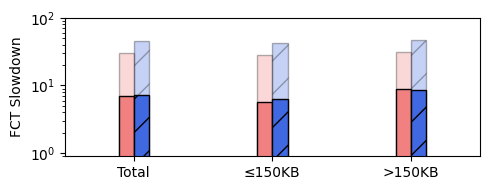

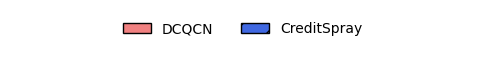

In [11]:


hatches = ['', '/', 'x', '-', '//', '+', '\\', '|', '*']
colors = ['#f18181', '#4068e1', '#ffd700', '#a9a9a9',
          '#8D6E63', '#512DA8', '#00bfff', '#228b22', '#F2C3A7']

#"harvest", "harvest-rtt", "hpcc", "hpcc-target1.5", "hpcc-target2", "poseidon", "powertcp", "theta-powertcp", "dcqcn", "dcqcn-limit", "timely", "timely-limit", "swift", "swift-25"
experiment_names_in_fig = ["DCQCN","CreditSpray"]
exp_is = [0,1]

# plot the line figure of average slowdown and p99 slowdown in one figure
fig, ax = plt.subplots(1, 1, figsize=(5, 2))

num_groups = 3
num_bars_per_group = len(exp_is)
# width of each bar
bar_width = 0.11

group_positions = np.arange(num_groups)
# bar_positions = [group_positions - num_bars_per_group // 2 *
#                 bar_width + i * bar_width for i in range(num_bars_per_group)]
offset = (num_bars_per_group - 1) / 2 * bar_width
bar_positions = [group_positions - offset + i *
                 bar_width for i in range(num_bars_per_group)]


def to_bar_log_slowdown(slowdown):
    # 0-4 are normal scale, other are log scale
    # if slowdown <= 2:
    #     return slowdown
    # else:
    #     return 2 + np.log10(slowdown) - np.log10(2)
    # return np.log10(slowdown)
    return slowdown


index = 0
labels = [experiment_names_in_fig[i] for i in exp_is]
for bar_idx, i in enumerate(exp_is):
    plt.bar(bar_positions[index], [to_bar_log_slowdown(s) for s in p99_slowdowns[i]][:-1],
            width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index % len(hatches)], color=colors[index % len(colors)], alpha=0.3)
    plt.bar(bar_positions[index], [to_bar_log_slowdown(s) for s in avg_slowdowns[i]][:-1], width=bar_width,
            linestyle='-', edgecolor='black', hatch=hatches[index % len(hatches)], color=colors[index % len(colors)], label=labels[bar_idx])
    # plt.bar(bar_positions[index], p99_priority_slowdowns[i], width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index], color=colors[index], alpha=0.3)
    # plt.bar(bar_positions[index], avg_priority_slowdowns[i], width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index], color=colors[index], label=experiment_names[i])
    index += 1

# ax.set_title("Average/P99 Slowdown")
# ax.set_xlabel("Flow Type")
ax.set_ylabel("FCT Slowdown")
# legend in two row
# ax.legend(bbox_to_anchor=(0.45, 0.6), ncol=2)
xticks = [i-0.065 for i in range(num_groups)]
ax.set_xlim(-0.5, num_groups-1+0.5)
ax.set_xticks(group_positions)
# xticklabels = ["Total", "(0,150KB]", "(150KB,)", "(3MB,)"]
xticklabels = ["Total", "≤150KB", ">150KB"]
ax.set_xticklabels(xticklabels)
# ax.grid()

# log scale
ax.set_yscale("log")
ax.set_ylim(0.9,100)
# yticks = list(range(11)) + [t*10 for t in list(range(2, 11))]
# ytlables = [1, 2, 10, 100]
# for t in yticks:
#     print(t)
#     print(to_bar_log_slowdown(t))
# ax.set_yticks([0,1,2,to_bar_log_slowdown(10),to_bar_log_slowdown(100)], [0,1,2,10,100])
# print([t if t in ytlables else "" for t in yticks])
# print(yticks)
# print([to_bar_log_slowdown(t) for t in yticks])
# ax.set_yticks([to_bar_log_slowdown(t) for t in yticks], [
#               t if t in ytlables else "" for t in yticks])

# ax.set_xlim(-0.75, 7.5)
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=7)
plt.tight_layout()
# plt.savefig(figure_name_prefix + figure_name_suffix +
#             experiment_suffix + "-Avg&P99inOne.png")
# save as eps
# plt.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
#             "-Avg&P99inOne.eps", bbox_inches='tight', dpi=600, format='eps')
# save as pdf
plt.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
            "-Avg&P99inOne.jpg", bbox_inches='tight', dpi=600, format='jpg')
plt.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
            "-Avg&P99inOne.pdf", bbox_inches='tight', dpi=600, format='pdf')

fig_legend, ax_legend = plt.subplots(1, 1, figsize=(6, 0.5))
ax_legend.axis('off')
# ax_legend.legend(handles = [plt.Line2D([0], [0], color=colors[i], label=labels[i]) for i in range(len(labels))], loc='center', ncol=3)
ax_legend.legend(*ax.get_legend_handles_labels(), loc='center',
                 ncol=len(experiment_names), frameon=False)
fig_legend.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
                   "-Avg&P99inOne" + "-legend.pdf", bbox_inches='tight', dpi=600, format='pdf')

# fig_legend.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix + "-legend.pdf", bbox_inches='tight', dpi=600, format='pdf')

In [12]:

from prettytable import PrettyTable

header = [""]+[flow_size_group[i]["name"] for i in range(len(flow_size_group))]
tab = PrettyTable(header)
for i in exp_is:
    tab.add_row([experiment_names_in_fig[i] + " avg"] + [avg_slowdowns[i][j] for j in range(len(flow_size_group))])
for i in exp_is:
    tab.add_row([experiment_names_in_fig[i] + " p99"] + [p99_slowdowns[i][j] for j in range(len(flow_size_group))])
    
print(tab)

+-----------------+--------------------+--------------------+--------------------+--------------------+
|                 |       Total        |     (0,150KB]      |      (150KB,)      |       (3MB,)       |
+-----------------+--------------------+--------------------+--------------------+--------------------+
|    DCQCN avg    | 7.004467882175057  | 5.666462987391555  | 8.861816899081932  | 13.413045070896123 |
| CreditSpray avg | 7.273226648527715  | 6.3023157537238585 |  8.62099480916655  | 14.164823025122985 |
|    DCQCN p99    | 29.96998854612818  | 28.06978972822675  | 31.155410558789477 | 29.543055013611454 |
| CreditSpray p99 | 44.675137406118935 | 42.23583763289961  | 46.939575436148765 | 47.753355571255945 |
+-----------------+--------------------+--------------------+--------------------+--------------------+


In [13]:
exp_is = [0, 1]
header = [""]+[flow_size_group[i]["name"] for i in range(len(flow_size_group))]
tab = PrettyTable(header)
for i in exp_is:
    print(experiment_names[i])
    tab.add_row([experiment_names_in_fig[i] + " avg"] + [avg_slowdowns[i][j] for j in range(len(flow_size_group))])
for i in exp_is:
    tab.add_row([experiment_names_in_fig[i] + " p99"] + [p99_slowdowns[i][j] for j in range(len(flow_size_group))])
    
print(tab)

DCQCN
creditspray
+-----------------+--------------------+--------------------+--------------------+--------------------+
|                 |       Total        |     (0,150KB]      |      (150KB,)      |       (3MB,)       |
+-----------------+--------------------+--------------------+--------------------+--------------------+
|    DCQCN avg    | 7.004467882175057  | 5.666462987391555  | 8.861816899081932  | 13.413045070896123 |
| CreditSpray avg | 7.273226648527715  | 6.3023157537238585 |  8.62099480916655  | 14.164823025122985 |
|    DCQCN p99    | 29.96998854612818  | 28.06978972822675  | 31.155410558789477 | 29.543055013611454 |
| CreditSpray p99 | 44.675137406118935 | 42.23583763289961  | 46.939575436148765 | 47.753355571255945 |
+-----------------+--------------------+--------------------+--------------------+--------------------+


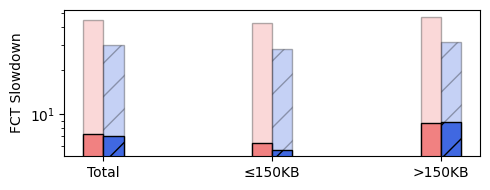

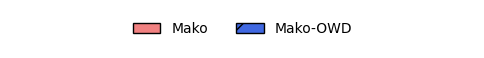

In [14]:


hatches = ['', '/', 'x', '-', '//', '+', '\\', '|', '*']
colors = ['#f18181', '#4068e1', '#ffd700', '#a9a9a9', '#512DA8', '#00bfff', '#228b22', '#F2C3A7']

#"harvest", "harvest-rtt", "hpcc", "hpcc-target1.5", "hpcc-target2", "poseidon", "powertcp", "theta-powertcp", "dcqcn", "dcqcn-limit", "timely", "timely-limit", "swift", "swift-25"
experiment_names_in_fig = ["Mako-OWD", "Mako", "HPCC", "HPCC*", "HPCC**", "Poseidon", "PowerTCP", "θ-PowerTCP", "DCQCN", "DCQCN*", "TIMELY", "TIMELY*", "Swift", "Swift*", "Mako-AGG"]

exp_is = [1, 0]

# plot the line figure of average slowdown and p99 slowdown in one figure
fig, ax = plt.subplots(1, 1, figsize=(5, 2))

num_groups = 3
num_bars_per_group = len(exp_is)
# width of each bar
bar_width = 0.12

group_positions = np.arange(num_groups)
#bar_positions = [group_positions - num_bars_per_group // 2 *
#                 bar_width + i * bar_width for i in range(num_bars_per_group)]
offset = (num_bars_per_group - 1) / 2 * bar_width
bar_positions = [group_positions - offset + i * bar_width for i in range(num_bars_per_group)]


def to_bar_log_slowdown(slowdown):
    # 0-4 are normal scale, other are log scale
    # if slowdown <= 2:
    #     return slowdown
    # else:
    #     return 2 + np.log10(slowdown) - np.log10(2)
    # return np.log10(slowdown)
    return slowdown


index = 0
labels = [experiment_names_in_fig[i] for i in exp_is]
for bar_idx, i in enumerate(exp_is):
    plt.bar(bar_positions[index], [to_bar_log_slowdown(s) for s in p99_slowdowns[i]][:-1],
            width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index % len(hatches)], color=colors[index % len(colors)], alpha=0.3)
    plt.bar(bar_positions[index], [to_bar_log_slowdown(s) for s in avg_slowdowns[i]][:-1], width=bar_width,
            linestyle='-', edgecolor='black', hatch=hatches[index % len(hatches)], color=colors[index % len(colors)], label=labels[bar_idx])
    # plt.bar(bar_positions[index], p99_priority_slowdowns[i], width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index], color=colors[index], alpha=0.3)
    # plt.bar(bar_positions[index], avg_priority_slowdowns[i], width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index], color=colors[index], label=experiment_names[i])
    index += 1

# ax.set_title("Average/P99 Slowdown")
# ax.set_xlabel("Flow Type")
ax.set_ylabel("FCT Slowdown")
# legend in two row
# ax.legend(bbox_to_anchor=(0.45, 0.6), ncol=2)
xticks = [i-0.065 for i in range(num_groups)]
ax.set_xticks(group_positions) 
# xticklabels = ["Total", "(0,150KB]", "(150KB,)", "(3MB,)"]
xticklabels = ["Total", "≤150KB", ">150KB"]
ax.set_xticklabels(xticklabels)
# ax.grid()

# log scale
ax.set_yscale("log")
# yticks = list(range(11)) + [t*10 for t in list(range(2, 11))]
# ytlables = [1, 2, 10, 100]
# for t in yticks:
#     print(t)
#     print(to_bar_log_slowdown(t))
# ax.set_yticks([0,1,2,to_bar_log_slowdown(10),to_bar_log_slowdown(100)], [0,1,2,10,100])
# print([t if t in ytlables else "" for t in yticks])
# print(yticks)
# print([to_bar_log_slowdown(t) for t in yticks])
# ax.set_yticks([to_bar_log_slowdown(t) for t in yticks], [
#               t if t in ytlables else "" for t in yticks])

# ax.set_xlim(-0.75, 7.5)
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=7)
plt.tight_layout()
# plt.savefig(figure_name_prefix + figure_name_suffix +
#             experiment_suffix + "-Avg&P99inOne.png")
# save as eps
# plt.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
#             "-Avg&P99inOne.eps", bbox_inches='tight', dpi=600, format='eps')
# save as pdf
# plt.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
#             "-Avg&P99inOne.jpg", bbox_inches='tight', dpi=600, format='jpg')
plt.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
            "-Avg&P99inOne-supp.pdf", bbox_inches='tight', dpi=600, format='pdf')

fig_legend, ax_legend = plt.subplots(1, 1, figsize=(6, 0.5))
ax_legend.axis('off')
# ax_legend.legend(handles = [plt.Line2D([0], [0], color=colors[i], label=labels[i]) for i in range(len(labels))], loc='center', ncol=3)
ax_legend.legend(*ax.get_legend_handles_labels(), loc='center', ncol=len(experiment_names), frameon=False)
fig_legend.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
            "-Avg&P99inOne-supp" + "-legend.pdf", bbox_inches='tight', dpi=600, format='pdf')

#fig_legend.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix + "-legend.pdf", bbox_inches='tight', dpi=600, format='pdf')


In [15]:

from prettytable import PrettyTable

header = [""]+[flow_size_group[i]["name"] for i in range(len(flow_size_group))]
tab = PrettyTable(header)
for i in exp_is:
    tab.add_row([experiment_names_in_fig[i] + " avg"] + [avg_slowdowns[i][j] for j in range(len(flow_size_group))])
for i in exp_is:
    tab.add_row([experiment_names_in_fig[i] + " p99"] + [p99_slowdowns[i][j] for j in range(len(flow_size_group))])
    
print(tab)

+--------------+--------------------+--------------------+--------------------+--------------------+
|              |       Total        |     (0,150KB]      |      (150KB,)      |       (3MB,)       |
+--------------+--------------------+--------------------+--------------------+--------------------+
|   Mako avg   | 7.273226648527715  | 6.3023157537238585 |  8.62099480916655  | 14.164823025122985 |
| Mako-OWD avg | 7.004467882175057  | 5.666462987391555  | 8.861816899081932  | 13.413045070896123 |
|   Mako p99   | 44.675137406118935 | 42.23583763289961  | 46.939575436148765 | 47.753355571255945 |
| Mako-OWD p99 | 29.96998854612818  | 28.06978972822675  | 31.155410558789477 | 29.543055013611454 |
+--------------+--------------------+--------------------+--------------------+--------------------+
